## Imports + configuration

In [ ]:
%pip install tqdm

In [1]:
import os
import glob
import json
import random
import math
from collections import deque

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from tqdm import tqdm

In [2]:
DATASET_DIR = "dataset"

IMAGE_SIZE = 64

BATCH_SIZE = 32
NUM_EPOCHS = 100
LEARNING_RATE = 2e-4

TIMESTEPS = 1000

RAW_MAP_CHANNELS = 3
DIRECTIONAL_CHANNELS = 4
MAP_CHANNELS = RAW_MAP_CHANNELS + DIRECTIONAL_CHANNELS
LATENT_CHANNELS = 16
BASE_CHANNELS = 64

TRAIN_RATIO = 0.9

NUM_WORKERS = 4
PREFETCH_FACTOR = 4
PERSISTENT_WORKERS = True

SEED = 42
EVAL_SEED = 2026

PATH_WEIGHT = 5.0

CHECKPOINT_DIR = (
    "checkpoints_cognitive_directional_capacity matched_"
    "x0_path_weighted"
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

print("Device:", DEVICE)
print("Conditioning input: obstacle/start/goal + up/down/left/right")
print("Map channels:", MAP_CHANNELS)

Device: cuda
Conditioning input: obstacle/start/goal + up/down/left/right
Map channels: 7


In [3]:
def build_directional_channels(
    obstacle_map,
):
    """
    Build four one-step legal-transition channels from the
    obstacle map only.

    Parameters
    ----------
    obstacle_map:
        [H, W] numpy array
        obstacle > 0.5 means blocked

    Returns
    -------
    directional:
        [4, H, W] float32

        channel 0: can move UP
        channel 1: can move DOWN
        channel 2: can move LEFT
        channel 3: can move RIGHT

    A transition is 1 only when both the current cell and the
    neighbouring destination cell are free.

    No start/goal, A*, or target-path information is used.
    """

    free = (
        obstacle_map < 0.5
    )

    H, W = free.shape

    up = np.zeros(
        (H, W),
        dtype=np.float32,
    )

    down = np.zeros(
        (H, W),
        dtype=np.float32,
    )

    left = np.zeros(
        (H, W),
        dtype=np.float32,
    )

    right = np.zeros(
        (H, W),
        dtype=np.float32,
    )

    # From (y, x), moving UP reaches (y-1, x)
    up[1:, :] = (
        free[1:, :]
        &
        free[:-1, :]
    ).astype(np.float32)

    # From (y, x), moving DOWN reaches (y+1, x)
    down[:-1, :] = (
        free[:-1, :]
        &
        free[1:, :]
    ).astype(np.float32)

    # From (y, x), moving LEFT reaches (y, x-1)
    left[:, 1:] = (
        free[:, 1:]
        &
        free[:, :-1]
    ).astype(np.float32)

    # From (y, x), moving RIGHT reaches (y, x+1)
    right[:, :-1] = (
        free[:, :-1]
        &
        free[:, 1:]
    ).astype(np.float32)

    directional = np.stack(
        [
            up,
            down,
            left,
            right,
        ],
        axis=0,
    )

    return directional


class MazePathDataset(Dataset):

    def __init__(
        self,
        dataset_dir,
    ):
        self.files = sorted(
            glob.glob(
                os.path.join(
                    dataset_dir,
                    "pair_*.npz",
                )
            )
        )

        if len(self.files) == 0:
            raise RuntimeError(
                f"No .npz files found in {dataset_dir}"
            )

        print(
            f"Found {len(self.files)} samples."
        )

    def __len__(self):
        return len(self.files)

    def __getitem__(
        self,
        idx,
    ):
        filepath = self.files[idx]

        with np.load(filepath) as data:

            raw_map = np.asarray(
                data["map"],
                dtype=np.float32,
            )

            path = np.asarray(
                data["path"],
                dtype=np.float32,
            )

        expected_raw_shape = (
            RAW_MAP_CHANNELS,
            IMAGE_SIZE,
            IMAGE_SIZE,
        )

        if raw_map.shape != expected_raw_shape:
            raise ValueError(
                f"{filepath}: expected raw map shape "
                f"{expected_raw_shape}, "
                f"got {raw_map.shape}"
            )

        obstacle = raw_map[0]

        directional = build_directional_channels(
            obstacle
        )

        grid_map = np.concatenate(
            [
                raw_map,
                directional,
            ],
            axis=0,
        ).astype(
            np.float32,
            copy=False,
        )

        expected_input_shape = (
            MAP_CHANNELS,
            IMAGE_SIZE,
            IMAGE_SIZE,
        )

        if grid_map.shape != expected_input_shape:
            raise ValueError(
                f"{filepath}: expected conditioning shape "
                f"{expected_input_shape}, "
                f"got {grid_map.shape}"
            )

        grid_map = torch.from_numpy(
            grid_map
        )

        path = torch.from_numpy(
            path
        )

        # {0, 1} -> {-1, 1}
        path = (
            path * 2.0 - 1.0
        )

        return {
            "map": grid_map,
            "path": path,
            "sample_index": int(idx),
        }

## Dataset loader

In [4]:
dataset = MazePathDataset(
    dataset_dir=DATASET_DIR
)

train_size = int(
    len(dataset) * TRAIN_RATIO
)

val_size = len(dataset) - train_size

split_generator = torch.Generator().manual_seed(
    SEED
)

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=split_generator
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

sample0 = dataset[0]

print("Map shape:", sample0["map"].shape)
print("Path shape:", sample0["path"].shape)

assert sample0["map"].shape == (
    MAP_CHANNELS,
    IMAGE_SIZE,
    IMAGE_SIZE,
)

# Sanity checks for directional channels.
directional_part = sample0["map"][
    RAW_MAP_CHANNELS:
]

assert directional_part.shape[0] == DIRECTIONAL_CHANNELS

print(
    "Directional channels:",
    directional_part.shape
)

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

if NUM_WORKERS > 0:
    loader_kwargs.update(
        persistent_workers=PERSISTENT_WORKERS,
        prefetch_factor=PREFETCH_FACTOR,
    )

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs,
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs,
)

Found 10000 samples.
Train: 9000
Validation: 1000
Map shape: torch.Size([7, 64, 64])
Path shape: torch.Size([1, 64, 64])
Directional channels: torch.Size([4, 64, 64])


## Cognitive Map Encoder

In [5]:
class CapacityMatchedDirectionalEncoder(nn.Module):
    """
    Capacity-matched directional CNN baseline.

    Input:
        7 channels

        0: obstacle
        1: start
        2: goal
        3: up
        4: down
        5: left
        6: right

    Output:
        16-channel latent conditioning map

    Architecture:
        7
        -> 32
        -> 48
        -> 54
        -> 34
        -> 16

    The hidden widths were chosen so that this encoder has
    approximately the same number of trainable parameters as
    the SR64 + Directional conditioning encoder.
    """

    def __init__(
        self,
        in_channels=MAP_CHANNELS,
        latent_channels=LATENT_CHANNELS,
    ):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(
                in_channels,
                32,
                kernel_size=3,
                padding=1,
            ),
            nn.GroupNorm(
                8,
                32,
            ),
            nn.SiLU(),

            nn.Conv2d(
                32,
                48,
                kernel_size=3,
                padding=1,
            ),
            nn.GroupNorm(
                8,
                48,
            ),
            nn.SiLU(),

            nn.Conv2d(
                48,
                54,
                kernel_size=3,
                padding=1,
            ),
            nn.GroupNorm(
                6,
                54,
            ),
            nn.SiLU(),

            nn.Conv2d(
                54,
                34,
                kernel_size=3,
                padding=1,
            ),
            nn.GroupNorm(
                2,
                34,
            ),
            nn.SiLU(),

            nn.Conv2d(
                34,
                latent_channels,
                kernel_size=3,
                padding=1,
            ),
        )

    def forward(
        self,
        grid_map,
    ):
        if grid_map.shape[1] != MAP_CHANNELS:
            raise ValueError(
                f"Expected {MAP_CHANNELS} channels, "
                f"got {grid_map.shape[1]}"
            )

        return self.encoder(
            grid_map
        )


encoder_check = (
    CapacityMatchedDirectionalEncoder()
)

encoder_params = sum(
    p.numel()
    for p in encoder_check.parameters()
    if p.requires_grad
)

REFERENCE_ENCODER_PARAMS = 61360

difference = (
    encoder_params
    -
    REFERENCE_ENCODER_PARAMS
)

difference_pct = (
    difference
    /
    REFERENCE_ENCODER_PARAMS
    *
    100.0
)

print(
    "Directional encoder parameters:",
    f"{encoder_params:,}"
)

print(
    "Reference encoder parameters:",
    f"{REFERENCE_ENCODER_PARAMS:,}"
)

print(
    "Difference:",
    f"{difference:+,}",
    f"({difference_pct:+.2f}%)"
)

Directional encoder parameters: 61,108
Reference encoder parameters: 61,360
Difference: -252 (-0.41%)


## Diffusion timestep embedding

In [6]:
class SinusoidalTimeEmbedding(nn.Module):

    def __init__(self, dim):

        super().__init__()

        self.dim = dim

    def forward(self, time):

        device = time.device

        half_dim = self.dim // 2

        embeddings = math.log(
            10000
        ) / (half_dim - 1)

        embeddings = torch.exp(
            torch.arange(
                half_dim,
                device=device
            )
            * -embeddings
        )

        embeddings = (
            time[:, None].float()
            *
            embeddings[None, :]
        )

        embeddings = torch.cat(
            (
                embeddings.sin(),
                embeddings.cos()
            ),
            dim=1
        )

        return embeddings

## UNet Residual Block

In [7]:
class ResBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        time_dim
    ):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm1 = nn.GroupNorm(
            8,
            out_channels
        )

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm2 = nn.GroupNorm(
            8,
            out_channels
        )

        self.time_mlp = nn.Linear(
            time_dim,
            out_channels
        )

        if in_channels != out_channels:

            self.residual = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1
            )

        else:

            self.residual = nn.Identity()

    def forward(
        self,
        x,
        time_emb
    ):

        residual = self.residual(x)

        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)

        # --------------------------------
        # timestep information
        # --------------------------------

        time_feature = self.time_mlp(
            time_emb
        )

        time_feature = time_feature[
            :,
            :,
            None,
            None
        ]

        h = h + time_feature

        h = self.conv2(h)
        h = self.norm2(h)
        h = F.silu(h)

        return h + residual

## Conditional UNet

In [8]:
class ConditionalUNet(nn.Module):

    def __init__(
        self,
        map_latent_channels=16,
        base_channels=64,
        time_dim=256
    ):

        super().__init__()

        input_channels = (
            1 + map_latent_channels
        )

        # ========================================
        # Time embedding
        # ========================================

        self.time_embedding = nn.Sequential(

            SinusoidalTimeEmbedding(
                time_dim
            ),

            nn.Linear(
                time_dim,
                time_dim
            ),

            nn.SiLU(),

            nn.Linear(
                time_dim,
                time_dim
            )
        )

        # ========================================
        # Input
        # ========================================

        self.input_conv = nn.Conv2d(
            input_channels,
            base_channels,
            kernel_size=3,
            padding=1
        )

        # ========================================
        # Encoder
        # ========================================

        self.down1 = ResBlock(
            base_channels,
            base_channels,
            time_dim
        )

        self.pool1 = nn.Conv2d(
            base_channels,
            base_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.down2 = ResBlock(
            base_channels,
            base_channels * 2,
            time_dim
        )

        self.pool2 = nn.Conv2d(
            base_channels * 2,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        # ========================================
        # Bottleneck
        # ========================================

        self.mid1 = ResBlock(
            base_channels * 2,
            base_channels * 4,
            time_dim
        )

        self.mid2 = ResBlock(
            base_channels * 4,
            base_channels * 4,
            time_dim
        )

        # ========================================
        # Decoder
        # ========================================

        self.up2 = nn.ConvTranspose2d(
            base_channels * 4,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.up_block2 = ResBlock(
            base_channels * 4,
            base_channels * 2,
            time_dim
        )

        self.up1 = nn.ConvTranspose2d(
            base_channels * 2,
            base_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.up_block1 = ResBlock(
            base_channels * 2,
            base_channels,
            time_dim
        )

        # ========================================
        # Output
        # ========================================

        self.output = nn.Conv2d(
            base_channels,
            1,
            kernel_size=1
        )

    def forward(
        self,
        x,
        timestep
    ):

        # timestep embedding
        t = self.time_embedding(
            timestep
        )

        # input
        x = self.input_conv(x)

        # ----------------------------------------
        # Down
        # ----------------------------------------

        skip1 = self.down1(
            x,
            t
        )

        x = self.pool1(
            skip1
        )

        skip2 = self.down2(
            x,
            t
        )

        x = self.pool2(
            skip2
        )

        # ----------------------------------------
        # Middle
        # ----------------------------------------

        x = self.mid1(
            x,
            t
        )

        x = self.mid2(
            x,
            t
        )

        # ----------------------------------------
        # Up
        # ----------------------------------------

        x = self.up2(x)

        x = torch.cat(
            [x, skip2],
            dim=1
        )

        x = self.up_block2(
            x,
            t
        )

        x = self.up1(x)

        x = torch.cat(
            [x, skip1],
            dim=1
        )

        x = self.up_block1(
            x,
            t
        )

        return self.output(x)

## DDPM noise schedule

In [9]:
class GaussianDiffusion:

    def __init__(
        self,
        timesteps=1000,
        beta_start=1e-4,
        beta_end=0.02,
        device="cuda"
    ):

        self.timesteps = timesteps
        self.device = device

        # ----------------------------------------
        # Linear beta schedule
        # ----------------------------------------

        self.betas = torch.linspace(
            beta_start,
            beta_end,
            timesteps,
            device=device
        )

        self.alphas = (
            1.0 - self.betas
        )

        self.alpha_cumprod = torch.cumprod(
            self.alphas,
            dim=0
        )

        self.alpha_cumprod_prev = F.pad(
            self.alpha_cumprod[:-1],
            (1, 0),
            value=1.0
        )

        self.sqrt_alpha_cumprod = (
            torch.sqrt(
                self.alpha_cumprod
            )
        )

        self.sqrt_one_minus_alpha_cumprod = (
            torch.sqrt(
                1.0
                -
                self.alpha_cumprod
            )
        )

        self.sqrt_recip_alphas = (
            torch.sqrt(
                1.0 / self.alphas
            )
        )

        # ----------------------------------------
        # Posterior variance
        # ----------------------------------------

        self.posterior_variance = (
            self.betas
            *
            (
                1.0
                -
                self.alpha_cumprod_prev
            )
            /
            (
                1.0
                -
                self.alpha_cumprod
            )
        )

## Helper

In [10]:
def extract(
    values,
    timestep,
    x_shape
):

    batch_size = timestep.shape[0]

    out = values.gather(
        0,
        timestep
    )

    return out.reshape(
        batch_size,
        *((1,) * (len(x_shape) - 1))
    )

## Forward diffusion

In [11]:
def q_sample(
    diffusion,
    x_start,
    timestep,
    noise=None
):

    if noise is None:
        noise = torch.randn_like(
            x_start
        )

    sqrt_alpha_cumprod_t = extract(
        diffusion.sqrt_alpha_cumprod,
        timestep,
        x_start.shape
    )

    sqrt_one_minus_alpha_cumprod_t = (
        extract(
            diffusion.sqrt_one_minus_alpha_cumprod,
            timestep,
            x_start.shape
        )
    )

    noisy_path = (
        sqrt_alpha_cumprod_t
        *
        x_start

        +

        sqrt_one_minus_alpha_cumprod_t
        *
        noise
    )

    return noisy_path, noise

In [12]:
class DiffusionPathPlanner(nn.Module):

    def __init__(
        self,
        latent_channels=LATENT_CHANNELS,
        base_channels=BASE_CHANNELS,
    ):
        super().__init__()

        self.map_encoder = CapacityMatchedDirectionalEncoder(
            in_channels=MAP_CHANNELS,
            latent_channels=latent_channels,
        )

        self.unet = ConditionalUNet(
            map_latent_channels=latent_channels,
            base_channels=base_channels,
        )

    def encode_map(self, grid_map):
        return self.map_encoder(grid_map)

    def predict_x0(
        self,
        noisy_path,
        map_latent,
        timestep,
    ):
        model_input = torch.cat(
            [
                noisy_path,
                map_latent,
            ],
            dim=1,
        )

        return self.unet(
            model_input,
            timestep,
        )

    def forward(
        self,
        grid_map,
        noisy_path,
        timestep,
    ):
        map_latent = self.encode_map(
            grid_map
        )

        return self.predict_x0(
            noisy_path,
            map_latent,
            timestep,
        )

## Training function

In [13]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    diffusion,
    device
):

    model.train()

    total_loss = 0.0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for batch in progress_bar:

        grid_map = batch["map"].to(
            device,
            non_blocking=True
        )

        path = batch["path"].to(
            device,
            non_blocking=True
        )

        batch_size = path.shape[0]

        # ----------------------------------------
        # Random timestep
        # ----------------------------------------

        timestep = torch.randint(
            0,
            diffusion.timesteps,
            (batch_size,),
            device=device
        ).long()

        # ----------------------------------------
        # Forward diffusion
        #
        # path = clean x0
        # noisy_path = x_t
        # ----------------------------------------

        noisy_path, _ = q_sample(
            diffusion,
            path,
            timestep
        )

        # ----------------------------------------
        # Predict clean x0
        # ----------------------------------------

        predicted_x0 = model(
            grid_map,
            noisy_path,
            timestep
        )

        # ============================================================
        # Weighted x0 reconstruction loss
        # ============================================================

        path_mask = (
            path > 0
        ).float()

        weights = (
            1.0
            +
            (PATH_WEIGHT - 1.0)
            *
            path_mask
        )

        squared_error = (
            predicted_x0
            -
            path
        ).pow(2)

        loss = (
            weights
            *
            squared_error
        ).mean()

        optimizer.zero_grad(
            set_to_none=True
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return (
        total_loss
        /
        len(loader)
    )

## Validation function

In [14]:
@torch.no_grad()
def validate(
    model,
    loader,
    diffusion,
    device
):

    model.eval()

    total_loss = 0.0

    for batch in loader:

        grid_map = batch["map"].to(
            device,
            non_blocking=True
        )

        path = batch["path"].to(
            device,
            non_blocking=True
        )

        batch_size = path.shape[0]

        timestep = torch.randint(
            0,
            diffusion.timesteps,
            (batch_size,),
            device=device
        ).long()

        # ----------------------------------------
        # Forward diffusion
        # ----------------------------------------

        noisy_path, _ = q_sample(
            diffusion,
            path,
            timestep
        )

        predicted_x0 = model(
            grid_map,
            noisy_path,
            timestep
        )

        path_mask = (
            path > 0
        ).float()

        weights = (
            1.0
            +
            (PATH_WEIGHT - 1.0)
            *
            path_mask
        )

        squared_error = (
            predicted_x0
            -
            path
        ).pow(2)

        loss = (
            weights
            *
            squared_error
        ).mean()

        total_loss += loss.item()

    return (
        total_loss
        /
        len(loader)
    )

In [15]:
os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True,
)

model = DiffusionPathPlanner(
    latent_channels=LATENT_CHANNELS,
    base_channels=BASE_CHANNELS,
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
)

diffusion = GaussianDiffusion(
    timesteps=TIMESTEPS,
    device=DEVICE,
)

total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Total trainable parameters:",
    f"{total_params:,}"
)

Total trainable parameters: 4,416,437


## Full training loop

In [16]:
best_val_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(
    1,
    NUM_EPOCHS + 1,
):

    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        diffusion,
        DEVICE,
    )

    val_loss = validate(
        model,
        val_loader,
        diffusion,
        DEVICE,
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Train loss: {train_loss:.6f}")
    print(f"Val loss:   {val_loss:.6f}")

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
        },
        os.path.join(
            CHECKPOINT_DIR,
            "latest.pt",
        ),
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
            },
            os.path.join(
                CHECKPOINT_DIR,
                "best.pt",
            ),
        )

        print(
            f"Saved new best model: "
            f"{best_val_loss:.6f}"
        )


Epoch 1/100


Train loss: 0.223437
Val loss:   0.165807
Saved new best model: 0.165807

Epoch 2/100


Train loss: 0.152112
Val loss:   0.140564
Saved new best model: 0.140564

Epoch 3/100


Train loss: 0.133026
Val loss:   0.131895
Saved new best model: 0.131895

Epoch 4/100


Train loss: 0.117603
Val loss:   0.125066
Saved new best model: 0.125066

Epoch 5/100


...

Train loss: 0.003034
Val loss:   0.070729

Epoch 97/100


Train loss: 0.002570
Val loss:   0.073053

Epoch 98/100


Train loss: 0.003689
Val loss:   0.077421

Epoch 99/100


Train loss: 0.003734
Val loss:   0.079652

Epoch 100/100


Train loss: 0.004244
Val loss:   0.077185


## Plot loss curve

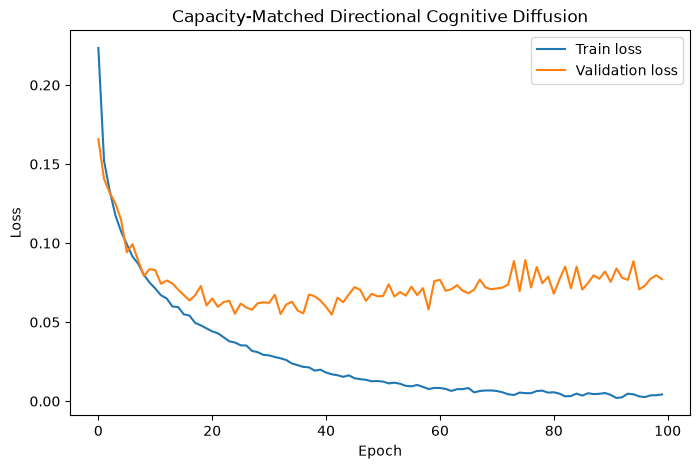

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Capacity-Matched Directional Cognitive Diffusion")
plt.legend()
plt.show()

In [18]:
best_checkpoint = torch.load(
    os.path.join(
        CHECKPOINT_DIR,
        "best.pt",
    ),
    map_location=DEVICE,
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

model.eval()

print(
    "Loaded best epoch:",
    best_checkpoint["epoch"]
)

print(
    "Best validation loss:",
    best_checkpoint["val_loss"]
)

Loaded best epoch: 42
Best validation loss: 0.054794577474240214


/tmp/ipykernel_6133/1778156898.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_checkpoint = torch.load(


## Reverse diffusion / inference

In [19]:
@torch.no_grad()
def p_sample(
    model,
    diffusion,
    x,
    map_latent,
    timestep,
    timestep_index
):

    # ========================================
    # Predict clean x0
    # ========================================

    predicted_x0 = model.predict_x0(
        x,
        map_latent,
        timestep
    )

    # Keep prediction in training data range
    predicted_x0 = torch.clamp(
        predicted_x0,
        -1.0,
        1.0
    )

    # ========================================
    # Extract diffusion coefficients
    # ========================================

    beta_t = extract(
        diffusion.betas,
        timestep,
        x.shape
    )

    alpha_t = extract(
        diffusion.alphas,
        timestep,
        x.shape
    )

    alpha_cumprod_t = extract(
        diffusion.alpha_cumprod,
        timestep,
        x.shape
    )

    alpha_cumprod_prev_t = extract(
        diffusion.alpha_cumprod_prev,
        timestep,
        x.shape
    )

    # ========================================
    # Posterior mean:
    #
    # q(x_{t-1} | x_t, x0)
    # ========================================

    coefficient_x0 = (
        torch.sqrt(
            alpha_cumprod_prev_t
        )
        *
        beta_t
        /
        (
            1.0
            -
            alpha_cumprod_t
        )
    )

    coefficient_xt = (
        torch.sqrt(
            alpha_t
        )
        *
        (
            1.0
            -
            alpha_cumprod_prev_t
        )
        /
        (
            1.0
            -
            alpha_cumprod_t
        )
    )

    model_mean = (
        coefficient_x0
        *
        predicted_x0
        +
        coefficient_xt
        *
        x
    )

    # ========================================
    # Final step: no additional noise
    # ========================================

    if timestep_index == 0:
        return model_mean

    # ========================================
    # Posterior variance
    # ========================================

    posterior_variance_t = extract(
        diffusion.posterior_variance,
        timestep,
        x.shape
    )

    noise = torch.randn_like(
        x
    )

    return (
        model_mean
        +
        torch.sqrt(
            posterior_variance_t
        )
        *
        noise
    )

In [20]:
@torch.no_grad()
def sample_path(
    model,
    diffusion,
    grid_map,
    device,
    show_progress=False,
):
    """
    Generate one path sample.

    IMPORTANT:
    During large validation runs, keep show_progress=False.
    This prevents 1000 nested tqdm progress bars from flooding
    Jupyter's output channel.
    """

    model.eval()

    grid_map = grid_map.to(
        device,
        non_blocking=True,
    )

    if grid_map.dim() == 3:
        grid_map = grid_map.unsqueeze(0)

    batch_size = grid_map.shape[0]

    # ========================================
    # Encode map ONCE
    # ========================================

    map_latent = model.encode_map(
        grid_map
    )

    # ========================================
    # Start from pure Gaussian noise
    # ========================================

    x = torch.randn(
        batch_size,
        1,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=device
    )

    # ========================================
    # Reverse diffusion
    # ========================================

    timestep_iterator = reversed(
        range(
            diffusion.timesteps
        )
    )

    if show_progress:
        timestep_iterator = tqdm(
            timestep_iterator,
            total=diffusion.timesteps,
            desc="Sampling",
            leave=False,
        )

    for i in timestep_iterator:

        timestep = torch.full(
            (batch_size,),
            i,
            device=device,
            dtype=torch.long
        )

        x = p_sample(
            model,
            diffusion,
            x,
            map_latent,
            timestep,
            i
        )

    # ========================================
    # [-1,1] -> [0,1]
    # ========================================

    x = (
        x + 1.0
    ) / 2.0

    x = torch.clamp(
        x,
        0.0,
        1.0
    )

    return x

## Predict on validation sample

In [21]:
def check_4neighbor_connection(
    binary_path,
    start,
    goal
):
    """
    binary_path: numpy array [H, W], bool
    start: (y, x)
    goal: (y, x)

    Returns:
        True if goal is reachable from start
        using only 4-neighbor path pixels.
    """

    H, W = binary_path.shape

    sy, sx = start
    gy, gx = goal

    # start / goal must both belong to path
    if not binary_path[sy, sx]:
        return False

    if not binary_path[gy, gx]:
        return False

    visited = np.zeros(
        (H, W),
        dtype=bool
    )

    queue = deque()

    queue.append(
        (sy, sx)
    )

    visited[sy, sx] = True

    directions = [
        (-1, 0),   # up
        (1, 0),    # down
        (0, -1),   # left
        (0, 1)     # right
    ]

    while queue:

        y, x = queue.popleft()

        # reached goal
        if (y, x) == (gy, gx):
            return True

        for dy, dx in directions:

            ny = y + dy
            nx = x + dx

            if (
                0 <= ny < H
                and
                0 <= nx < W
            ):

                if (
                    binary_path[ny, nx]
                    and
                    not visited[ny, nx]
                ):

                    visited[ny, nx] = True

                    queue.append(
                        (ny, nx)
                    )

    return False

In [22]:
@torch.no_grad()
def evaluate_single_sample(
    model,
    diffusion,
    sample,
    device,
    threshold=0.5
):
    """
    Evaluate one generated path.
    """

    grid_map = sample["map"]

    # ========================================
    # Generate predicted path
    # Inner diffusion progress is DISABLED.
    # ========================================

    predicted_path = sample_path(
        model,
        diffusion,
        grid_map,
        device,
        show_progress=False,
    )

    pred = (
        predicted_path[0, 0]
        .detach()
        .cpu()
        .numpy()
    )

    binary_path = (
        pred > threshold
    )

    # ========================================
    # Extract raw-map channels
    # ========================================

    obstacle = (
        grid_map[0]
        .cpu()
        .numpy()
        > 0.5
    )

    start_map = (
        grid_map[1]
        .cpu()
        .numpy()
        > 0.5
    )

    goal_map = (
        grid_map[2]
        .cpu()
        .numpy()
        > 0.5
    )

    start_y, start_x = np.where(
        start_map
    )

    goal_y, goal_x = np.where(
        goal_map
    )

    if len(start_y) != 1:
        raise ValueError(
            "Expected exactly one start cell."
        )

    if len(goal_y) != 1:
        raise ValueError(
            "Expected exactly one goal cell."
        )

    start = (
        int(start_y[0]),
        int(start_x[0])
    )

    goal = (
        int(goal_y[0]),
        int(goal_x[0])
    )

    sy, sx = start
    gy, gx = goal

    start_in_path = bool(
        binary_path[sy, sx]
    )

    goal_in_path = bool(
        binary_path[gy, gx]
    )

    collision_mask = (
        binary_path
        &
        obstacle
    )

    collision_count = int(
        collision_mask.sum()
    )

    collision_free = (
        collision_count == 0
    )

    connected = (
        check_4neighbor_connection(
            binary_path,
            start,
            goal
        )
    )

    return {
        "start_in_path": start_in_path,
        "goal_in_path": goal_in_path,
        "collision_free": collision_free,
        "collision_count": collision_count,
        "connected": connected,
    }

In [23]:
def summarize_results(
    results
):

    total = len(
        results
    )

    if total == 0:
        print(
            "No results to summarize."
        )
        return

    start_rate = np.mean(
        [
            r["start_in_path"]
            for r in results
        ]
    )

    goal_rate = np.mean(
        [
            r["goal_in_path"]
            for r in results
        ]
    )

    collision_free_rate = np.mean(
        [
            r["collision_free"]
            for r in results
        ]
    )

    connected_rate = np.mean(
        [
            r["connected"]
            for r in results
        ]
    )

    avg_collisions = np.mean(
        [
            r["collision_count"]
            for r in results
        ]
    )

    valid_success = np.mean(
        [
            (
                r["start_in_path"]
                and
                r["goal_in_path"]
                and
                r["collision_free"]
                and
                r["connected"]
            )
            for r in results
        ]
    )

    print(
        f"Samples evaluated: {total}"
    )

    print(
        f"Start included:      "
        f"{start_rate * 100:.2f}%"
    )

    print(
        f"Goal included:       "
        f"{goal_rate * 100:.2f}%"
    )

    print(
        f"Collision-free:      "
        f"{collision_free_rate * 100:.2f}%"
    )

    print(
        f"Connected S -> G:    "
        f"{connected_rate * 100:.2f}%"
    )

    print(
        f"Average collisions:  "
        f"{avg_collisions:.2f}"
    )

    print(
        f"Valid Path Success:  "
        f"{valid_success * 100:.2f}%"
    )

    return float(
        valid_success
    )

In [24]:
@torch.no_grad()
def evaluate_validation_set(
    model,
    diffusion,
    dataset,
    device,
    num_samples=1000,
    threshold=0.5,
    desc="Evaluating",
):
    model.eval()

    num_samples = min(
        num_samples,
        len(dataset)
    )

    results = []

    progress = tqdm(
        range(num_samples),
        desc=desc,
        total=num_samples,
        dynamic_ncols=True,
    )

    for idx in progress:

        sample = dataset[idx]

        result = evaluate_single_sample(
            model=model,
            diffusion=diffusion,
            sample=sample,
            device=device,
            threshold=threshold,
        )

        result["index"] = int(idx)
        result["sample_index"] = int(
            sample["sample_index"]
        )

        results.append(result)

        valid_count = sum(
            (
                r["start_in_path"]
                and
                r["goal_in_path"]
                and
                r["collision_free"]
                and
                r["connected"]
            )
            for r in results
        )

        progress.set_postfix(
            success=(
                f"{100.0 * valid_count / len(results):.1f}%"
            )
        )

    return results

In [25]:
random.seed(EVAL_SEED)
np.random.seed(EVAL_SEED)
torch.manual_seed(EVAL_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(EVAL_SEED)

results = evaluate_validation_set(
    model=model,
    diffusion=diffusion,
    dataset=val_dataset,
    device=DEVICE,
    num_samples=1000,
    threshold=0.5,
    desc="Capacity-matched directional CNN",
)

valid_success = summarize_results(results)

print()
print(
    "Final Valid Path Success:",
    f"{valid_success * 100:.2f}%"
)

Capacity-matched directional CNN: 100%|██████████| 1000/1000 [48:36<00:00,  2.92s/it, success=82.3%]

Samples evaluated: 1000
Start included:      100.00%
Goal included:       100.00%
Collision-free:      98.80%
Connected S -> G:    83.20%
Average collisions:  0.02
Valid Path Success:  82.30%

Final Valid Path Success: 82.30%
